# Jeu de traces simulées à partir d'un réseau

Nous présentons ici un exemple simple et complet reposant sur une collection de traces simulées à partir d’un réseau. Le réseau est un extrait de la BDTOPO situé sur un versant de montagne en face de la ville de Chamonix, il représente un cas non complexe de tronçons.

Ce pipeline est exécuté en une seule itération.



## Import des librairies

- Les deux librairies socles : tracklib et footprint2graph 
- Pour visualiser les résultats : matplotlib

In [1]:
import os
import sys

import matplotlib.pyplot as plt

# Ajout dans la variable PATH du système du chemin où est installée la librairie tracklib
module_path = os.path.abspath(os.path.join('../../../../tracklib'))
if module_path not in sys.path:
    sys.path.append(module_path)
# Alias pour tracklib
import tracklib as tkl

# Ajout dans la variable PATH du système du chemin où est installée la librairie footprint2graph
module_path = os.path.abspath(os.path.join('../../..'))
if module_path not in sys.path:
    sys.path.append(module_path)



## Import des données : réseau puis traces simulées

Number of edges= 7
Number of nodes= 8



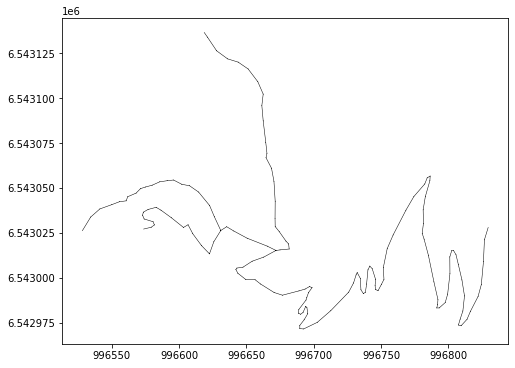

In [2]:
# WKT;link_id;source;target;direction;wkt_source;wkt_target
fmt = tkl.NetworkFormat({
       "pos_edge_id": 1,
       "pos_source": 2,
       "pos_target": 3,
       "pos_wkt": 0,
       "srid": "ENU",
       "separator": ";",
       "header": 1})
netpath = os.path.abspath(os.path.join('../../../data/network2.csv'))
network = tkl.NetworkReader.readFromFile(netpath, fmt, verbose=False)

plt.figure(figsize=(8, 6))
network.plot('k-', '', 'g-', 'r-', 0.5, plt)

print ('Number of edges=', len(network.EDGES))
print ('Number of nodes=', len(network.NODES))
print ('')

100% (1000 of 1000) |####################| Elapsed Time: 0:00:18 Time:  0:00:180001


------------------------------------------------------------
877 (87.7 %) tracks generated on network
------------------------------------------------------------


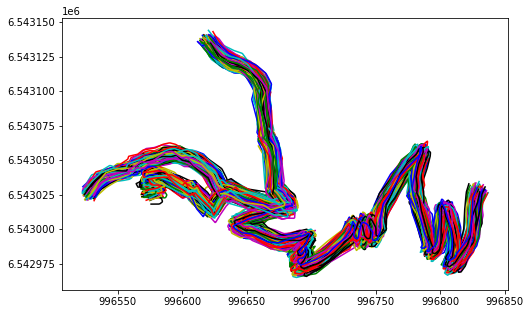

In [3]:
tkl.stochastics.seed(333)
#
noiser = tkl.NoiseProcess(amps=2.5, kernels=tkl.ExponentialKernel(80))

# generate simulated trajectories from the network 
collection = tkl.generateTracksOnNetwork(network, N=1000, p_round_trip=0.05, p_cplx_trip=0.10, resolution=1, noiser=noiser)

# add 3 attributes
for idx, track in enumerate(collection):
    track.createAnalyticalFeature('TID', idx+1)

#
plt.figure(figsize=(8, 5))
collection.plot(append=plt)

## Dossier de stockage des résultats

In [4]:
from footprint2graph import prepareEnv, setupEnv, logEnv

RESPATH = r'/home/md_vandamme/7_LIB/Footprint2graph-pipeline/test/result11/'

import os
import shutil

# Suppression des répertoires
prepareEnv(RESPATH)

# Création des répertoires
iteration_index = 1
setupEnv(RESPATH, iteration_index)

# Log environment information
logEnv(RESPATH)

#  On définit un format pour le stockage des traces modifiées dans le pipeline
fmt = tkl.TrackFormat({'ext': 'CSV',
                       'srid': 'ENU',
                       'id_E': 1, 'id_N': 0, 'id_U': 3, 'id_T': 2,
                       'time_fmt': '2D/2M/4Y 2h:2m:2s',
                       'separator': ';',
                       'header': 0,
                       'cmt': '#',
                       'read_all': True})

pipeline_idx = 1

## Step 1 : segmentation and resampling

In [5]:
from footprint2graph import segmentation_resample

# Paramètre : Nombre de points minimum pour un morceau de trace au moment du découpage
#             si le nombre n'est pas atteint, le morceau de trace est oublié
NB_OBS_MIN           = 10

# Paramètre : Distance en mètres entre 2 points, si supérieure au seuil on coupe la trace
DIST_MAX_2OBS        = 50


RESAMPLE_SIZE_GRID = 1
RESAMPLE_SIZE_FUSION = 5

# =============================================================================
#  On définit un format pour le stockage des traces modifiées dans le pipeline

segmentation_resample(RESPATH, collection, fmt, NB_OBS_MIN, DIST_MAX_2OBS,
                    RESAMPLE_SIZE_GRID, RESAMPLE_SIZE_FUSION)





Starting segmentation and resampling...
Starting segmentation ...
     500 / 877
    Number of tracks after segmentation: 877
Finished saving segmented tracks.
Starting resampling ...
    Number of tracks to resample:  877
    Number of tracks after resampling: 877
    Number of tracks after resampling: 877
Finished saving resampled tracks.
Stage 1 finished: segmentation and resampling.


In [6]:
print ('affiche des résultats ??')

affiche des résultats ??


## Step 2 : calculs des cartes de densités, de constraste et binaire

In [7]:
from footprint2graph import density_polygonize

# Définition des grilles géométrique et contraste
G1_SIZE              = 2
G2_SIZE              = 30

SEUIL_DENSITE = 25    # pas d'unité 
SEUIL_SURFACE = 1000  # m2

cut_factor  = 5

interp_dist = 5
clean_dist  = 0

density_polygonize(RESPATH, G1_SIZE, G2_SIZE, SEUIL_DENSITE, SEUIL_SURFACE,
                       pipeline_idx, cut_factor=cut_factor, interp_dist=interp_dist, clean_dist=clean_dist)


Starting rasterization and vectorization (iteration 1) 
    Loading tracks from :  resample_grid
    Number of tracks to load:  877
    Building high-resolution geometry density grid G1 :  2 m ...
    Building low-resolution contextual density grid G2 :  30 m ...
    Assigning track points to the G1 and G2 grids
         500 / 877
    Computing G1 ...
    Computing G2 ...
    Number of neighboring cells to consider: 7
    Building contrast grid :  2 m
    Execution time (seconds): 7.25739049911499
    Finished heatmap computation.
Starting morphological closingImage ...


100% (291 of 291) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (287 of 287) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 1417) |                       | Elapsed Time: 0:00:00 ETA:  --:--:--

    Execution time (seconds): 0.24849605560302734
    Finished morphological opening.
Vectorizing cleaned image ...
Extracting road surface vector features ...
    Number of polygonize features:  3
    Number of polygonize features copied:  2
    Execution time (seconds): 0.024357318878173828
    Vectorization completed.
Smoothing polygon to remove stair-step artifacts ...
    Execution time (seconds): 0.08345317840576172
    Road surface smoothing completed.
Starting centerline computation ...


100% (1417 of 1417) |####################| Elapsed Time: 0:00:00 Time:  0:00:00


    Execution time (seconds): 0.18981075286865234
    Centerline computed.
Stage 2 completed: rasterization and vectorization.


/home/md_vandamme/.local/lib/python3.10/site-packages/pyogrio/raw.py:200: RuntimeWarning: /home/md_vandamme/7_LIB/Footprint2graph-pipeline/test/result11/image/road_surface_lissee_1.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


Text(0.5, 1.0, 'Road surface lissée')

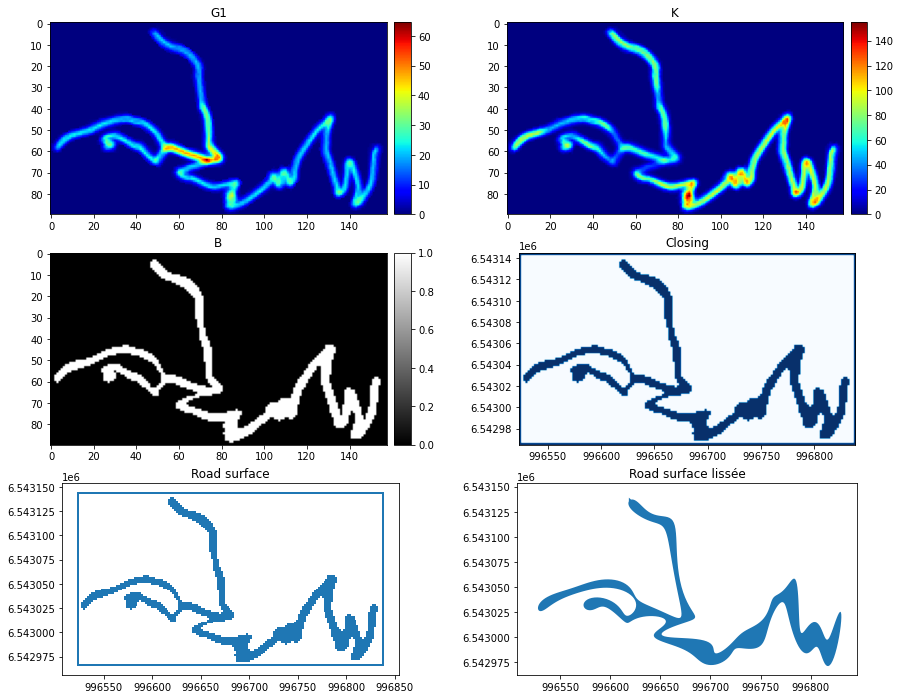

In [8]:
from footprint2graph.util.PlotRes import matPlotShapefile, matPlotRasterShp, maPlotRasterTiff

plt.figure(figsize=(15, 12))

# ----------------------------------------------------------------------------------------------------------
ax1 = plt.subplot2grid((3, 2), (0, 0))
rasterG1 = tkl.RasterReader.readFromAscFile(RESPATH + 'image/G1_1.asc', name='G1', separator='\t')
mapDensity = rasterG1.getAFMap('G1')
mapDensity.plotAsImage(cmap='jet', vmin=0, append=ax1)

# ----------------------------------------------------------------------------------------------------------
ax2 = plt.subplot2grid((3, 2), (0, 1))
rasterK = tkl.RasterReader.readFromAscFile(RESPATH + 'image/K_1.asc', name='K', separator='\t')
mapContraste = rasterK.getAFMap('K')
mapContraste.plotAsImage(cmap='jet', append=ax2)

# ----------------------------------------------------------------------------------------------------------
ax3 = plt.subplot2grid((3, 2), (1, 0))
rasterB = tkl.RasterReader.readFromAscFile(RESPATH + 'image/B_1.asc', name='B', separator='\t')
mapBinaire = rasterB.getAFMap('B')
mapBinaire.plotAsImage(append=ax3)

# ----------------------------------------------------------------------------------------------------------
ax4 = plt.subplot2grid((3, 2), (1, 1))
#if closing:
maPlotRasterTiff(RESPATH, 'image/erosion_1.tif', ax4)
ax4.set_title('Closing')
#else:
#    maPlotRasterTiff(RESPATH, 'image/imageclean_1.tif', ax4)
#    ax4.set_title('Comble trou')

# ----------------------------------------------------------------------------------------------------------
ax5 = plt.subplot2grid((3, 2), (2, 0))
matPlotRasterShp(RESPATH, 'image/road_surface_1.shp', ax5)
ax5.set_title('Road surface')

# ----------------------------------------------------------------------------------------------------------
ax6 = plt.subplot2grid((3, 2), (2, 1))
matPlotRasterShp(RESPATH, 'image/road_surface_lissee_1.shp', ax6)
ax6.set_title('Road surface lissée')

## Step 3 : création de la center line

In [9]:
from footprint2graph import addTopologyToNetwork

SEARCH = 25
h = 5
addTopologyToNetwork(RESPATH, SEARCH, h, pipeline_idx)

fmt = tkl.NetworkFormat({
           "pos_edge_id": 0,
           "pos_source": 1,
           "pos_target": 2,
           "pos_wkt": 4,
           "srid": "ENU",
           "separator": ",",
           "header": 1})
    
networkpath = RESPATH + 'network/reseau_1.csv'
squelette = tkl.NetworkReader.readFromFile(networkpath, fmt, verbose=False)
print ('-----------------------------------------------------------------')

100% (16 of 16) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00


Starting topology creation for the network
    Number of edges in the skeleton: 279
    Finished loaded skeleton.
Finished removing hooked parts of the skeleton.
Finished simplification of the skeleton.
    Number of edges in the simplified skeleton: 15
    Number of nodes: 16
    Conflation cannot be performed for node  0 ; the three incident edges are too long: 33 64 122
    Conflation cannot be performed for node  11 ; the three incident edges are too long: 33 191 167
    Edge count after conflation: 5
Stage 3 completed: adding topology to the skeleton.
-----------------------------------------------------------------


/home/md_vandamme/.local/lib/python3.10/site-packages/pyogrio/raw.py:200: RuntimeWarning: /home/md_vandamme/7_LIB/Footprint2graph-pipeline/test/result11/image/road_surface_lissee_1.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


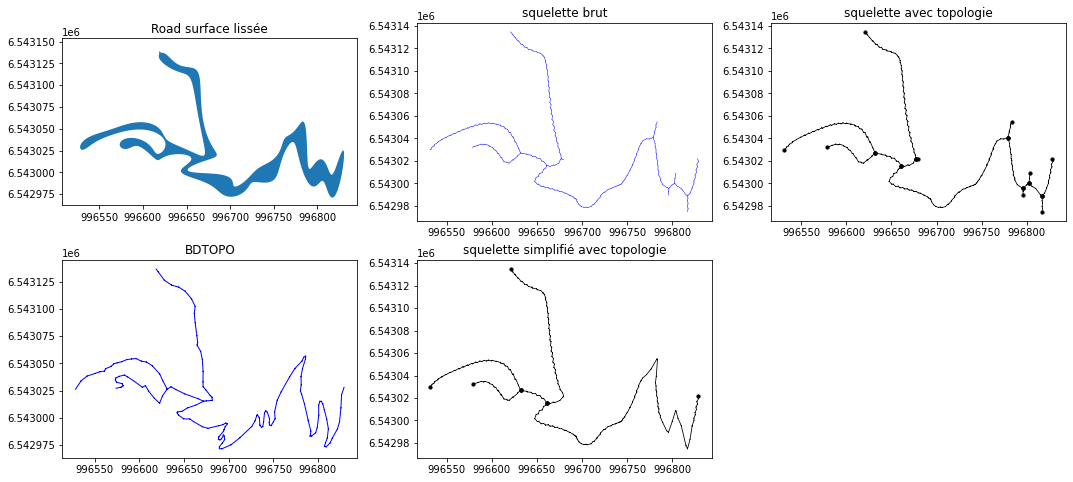

In [10]:
from footprint2graph.util.PlotRes import plotSqueletteTopo

plt.figure(figsize=(18, 8))

ax1 = plt.subplot2grid((2, 3), (0, 0))
matPlotRasterShp(RESPATH, 'image/road_surface_lissee_1.shp', ax1)
ax1.set_title('Road surface lissée')

ax2 = plt.subplot2grid((2, 3), (0, 1))
matPlotShapefile(RESPATH + 'network/', 'squelette_1.shp', ax2)
ax2.set_title('squelette brut')

ax3 = plt.subplot2grid((2, 3), (0, 2))
plotSqueletteTopo(RESPATH, ax3)
ax3.set_title('squelette avec topologie')

ax4 = plt.subplot2grid((2, 3), (1, 0))
network.plot(edges='b-', size=1.0, append=ax4)
ax4.set_title('BDTOPO')

ax5 = plt.subplot2grid((2, 3), (1, 1))
squelette.plot('k-', nodes='ko', size=0.8, append=ax5)
ax5.set_title('squelette simplifié avec topologie')

print ('')

## Step 4 : Construction des géométries agrégées pour chaque arc du squelette

1. Attribue les points des traces brutes à chaque arc de la topologie
	- Recalage avec l’algorithme de Newson and Krumm (2009)
2. Reconstruit les bons morceaux de traces candidats pour chaque arc de la topologie
3. Agrégation des morceaux de traces
4. Conflation des traces fusionnées afin d’obtenir un réseau de mobilité   

In [11]:
from footprint2graph import createNetworkGeom

SEARCH = 25
BUFFER = 20
createNetworkGeom(RESPATH, SEARCH, BUFFER, pipeline_idx)

Starting map-matching, aggregation, and conflation of GNSS trajectories.
Loading network (1) ...
    Number of edges =  5
    Number of nodes =  6
    Total segment length of the network =  765.9881721625043
    Loading collection of tracks ...


100% (6 of 6) |##########################| Elapsed Time: 0:00:00 Time:  0:00:00


    Number of tracks: 877
    Execution time (seconds): 0.6212308406829834
Starting map-matching ...
Map-matching preparation...
    PARAMETER search_radius:  25
    Map-matching ended.
    Execution time (seconds): 12.402592897415161
    Map-matching results exported.
    Number of map-matched points = 49111 (89.82 %)
    Map-matching results restructuring completed.
Starting construction of candidate trajectory segments for each topology edge ...
    265  candidates for edge 15
    571  candidates for edge 12
    264  candidates for edge 16
    189  candidates for edge 17
    235  candidates for edge 21
    Number of processed edges:  5
    Minimum number of candidate tracks per edge:  189
    Maximum number of candidate traces per edge:  571
    Average number of candidate tracks per edge:  305
    Segment construction completed.
    Execution time (seconds): 4.6723151206970215
Starting aggregation ...
    Aggregation for arc number: 15
        Number of candidate tracks / number of

### Visualisation du recalage sur le réseau

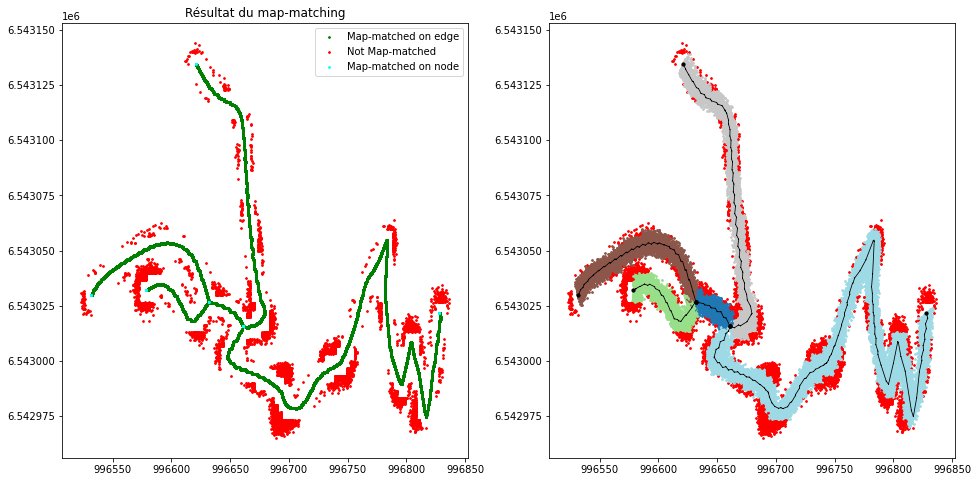

In [12]:
from footprint2graph.util.PlotRes import plotMM

plotMM(RESPATH, squelette)
plt.show()

### Visualisation des candidats pour l'agrégation

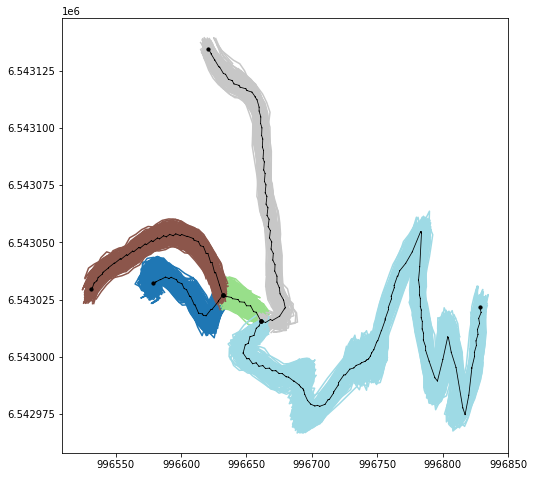

In [13]:
from footprint2graph.util.PlotRes import plotSegmentsConstruction

plt.figure(figsize=(8, 8))

ax1 = plt.subplot2grid((1, 1), (0, 0))
plotSegmentsConstruction(RESPATH, ax1, squelette)

### Visualisation de l'agrégation et de la conflation

Text(0.5, 1.0, 'CONFLATION')

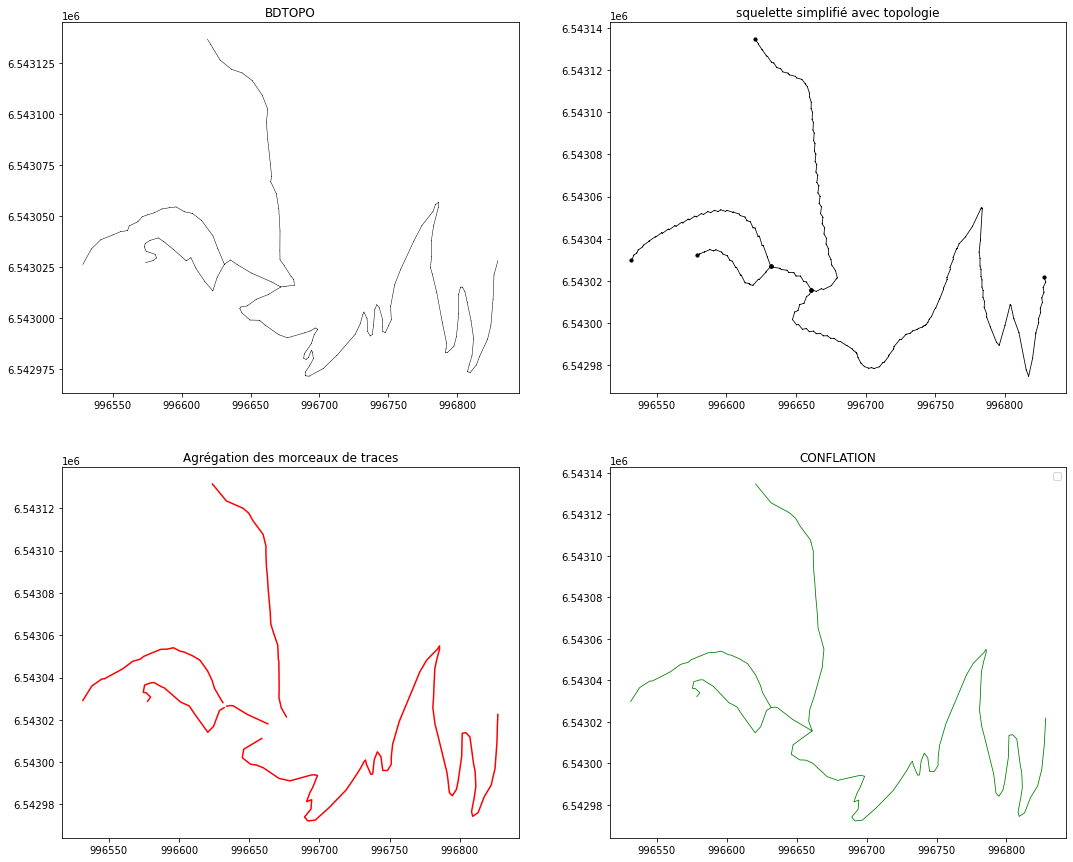

In [14]:
from footprint2graph.util.PlotRes import plotAggregation, plotConflation
import os

plt.figure(figsize=(18, 15))

# ---------------------------------------------------
ax1 = plt.subplot2grid((2, 2), (0, 0))
network.plot('k-', '', 'g-', 'r-', 0.5, ax1)
ax1.set_title('BDTOPO')

# ---------------------------------------------------
ax2 = plt.subplot2grid((2, 2), (0, 1))
squelette.plot('k-', nodes='ko', size=0.8, append=ax2)
ax2.set_title('squelette simplifié avec topologie')

# ---------------------------------------------------
ax3 = plt.subplot2grid((2, 2), (1, 0))
plotAggregation(RESPATH, ax3)
ax3.set_title('Agrégation des morceaux de traces')

# ---------------------------------------------------
ax4 = plt.subplot2grid((2, 2), (1, 1))
plotConflation(RESPATH, ax4)
ax4.set_title('CONFLATION')


## Visualisation du résultat final

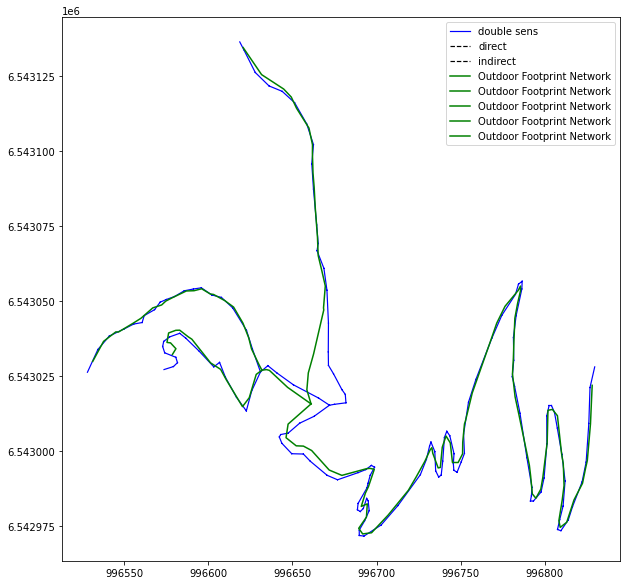

In [15]:
plt.figure(figsize=(10, 10))
ax = plt.subplot2grid((1, 1), (0, 0))

network.plot('b-', nodes='', size=1.2, append=plt)
plotConflation(RESPATH, ax, size=1.5, label='Outdoor Footprint Network')

plt.legend()